In [1]:
# Run this code if your virtual environment does not have the required libraries installed. 
# You only need to run this once per environment.
!pip install keras tensorflow matplotlib.pyplt numpy 

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplt (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplt

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

###############################################################################
# Function Definitions
###############################################################################

##################################
# 1. Build Perceptrons
##################################
def buildModel(dim):
    model = Sequential()
    model.add(Dense(1, input_dim=dim))
    model.add(Activation('hard_sigmoid'))
    return model
    
   
##################################
# 3. History Plotting
##################################
def plotHistory(history, name):
    
    # # History Data
    # print(history.history.keys())
    # print(history.history['accuracy'])
    # print(history.history['val_accuracy'])
    # print(history.history['loss'])
    # print(history.history['val_loss'])
    
    # Accuracy Plot
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.ylabel('Accuracy')
    plt.xlabel('Epochs')
    plt.title('Accuracy for %s' %(name))
    plt.legend(['Training', 'Validation'])
    plt.show()
    
    # Loss Plot
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.ylabel('Loss')
    plt.xlabel('Epochs')
    plt.title('Loss for %s' %(name))
    plt.legend(['Training', 'Validation'])
    plt.show()


def plotDecision(xMatrix, yMatrix, weights, model):
    # Plotting points
    x = np.array(xMatrix[:,0].T)
    x = x.flatten()
    
    y = np.array(xMatrix[:,1].T)
    y = y.flatten()
    
    colors = np.array(yMatrix.T)
    colors = colors.flatten()
    
    
    plt.scatter(x, y, c=colors, cmap=plt.cm.Paired)
    plt.colorbar()
    
    # Plotting decision regions
    x_min, x_max = x.min() - 0.1, x.max() + 0.1
    y_min, y_max = y.min() - 0.1, y.max() + 0.1
    
#    print(x_min,x_max,y_min,y_max)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict_on_batch(np.c_[xx.ravel(), yy.ravel()]) 

    Z = Z.reshape(xx.shape)   
    plt.contour(xx, yy, Z, 1, cmap=plt.cm.Paired)
    
    plt.ylim([x_min,x_max])
#    plt.xlim([y_min,y_max])
    plt.show()



###############################################################################
# Main Body of Code
###############################################################################
np.random.seed(1)
##################################
# 1. Build Perceptrons
##################################
p1model = buildModel(1)
p2model = buildModel(2)

adam = Adam(learning_rate=0.05, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)
p1model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
p2model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])



##################################
# 2. Build Boolean Matrices
##################################
xOne = np.asmatrix('1; 0')
xTwo = np.asmatrix('1,1; 1,0; 0,1; 0,0')
yNot = np.asmatrix('0;1')
yOr = np.asmatrix('1;1;1;0')
yAnd = np.asmatrix('1;0;0;0')
yXOR = np.asmatrix('0;1;1;0')


#Validation matrices
xOneVal = np.asmatrix('1')
xTwoVal = np.asmatrix('1,1; 1,0')
yNotVal = np.asmatrix('0')
yOrVal = np.asmatrix('1;1')
yAndVal = np.asmatrix('1;0')
yXORVal = np.asmatrix('0;1')


##################################
# 3. Build Nut Matrices
##################################
xNut = np.asmatrix('2.2,1.4; 1.5,1; 0.6,0.5; 2.3,2.0; 1.3,1.5; 0.3,1')
xNutVal = np.asmatrix('2.2,1.4; 0.3,1')

yNut = np.asmatrix('0;0;0;1;1;1')
yNutVal = np.asmatrix('0;1')

##################################
# 4. Train NOT dataset
##################################
es = keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=0, verbose=1, mode='auto')
NOThistory = p1model.fit(xOne, yNot, validation_data=(xOneVal, yNotVal), epochs=2000, batch_size=1, verbose=1, callbacks=[es])



Epoch 1/2000


c:\Users\codeh\471Book\jnb_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\codeh\471Book\jnb_env\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5000 - loss: 0.6460 - val_accuracy: 1.0000 - val_loss: 0.5875
Epoch 2/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.6350 - val_accuracy: 1.0000 - val_loss: 0.5599
Epoch 3/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.6186 - val_accuracy: 1.0000 - val_loss: 0.5456
Epoch 4/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.6122 - val_accuracy: 1.0000 - val_loss: 0.5232
Epoch 5/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.5977 - val_accuracy: 1.0000 - val_loss: 0.5084
Epoch 6/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.5915 - val_accuracy: 1.0000 - val_loss: 0.4881
Epoch 7/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.5779 - val_accuracy: 1.0000 - val_loss: 0.4739
Epoch 8/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.5685 - val_accuracy: 1.0000 - val_loss: 0.4

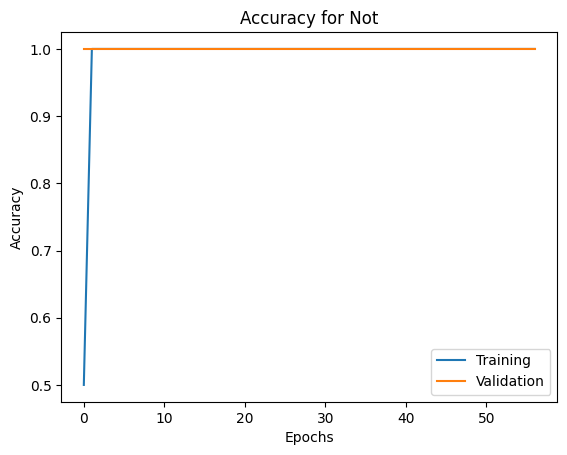

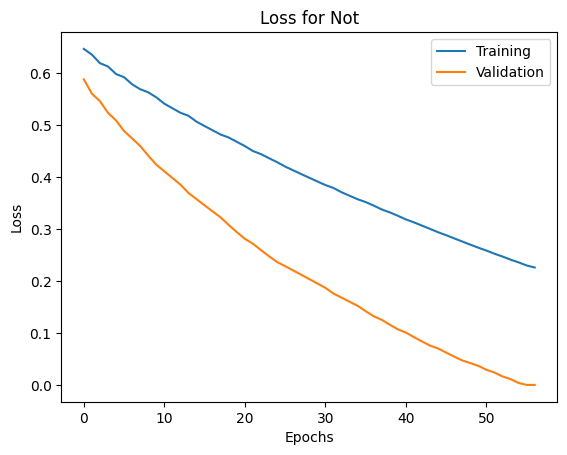

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 0.2225
loss: 0.22
compile_metrics: 100.00%


In [3]:
##################################
# 5 Plot Results
##################################

plotHistory(NOThistory, 'Not')

score = p1model.evaluate(xOne, yNot, batch_size=2, verbose=1)
print("%s: %.2f" % (p1model.metrics_names[0], score[0]))
print("%s: %.2f%%" % (p1model.metrics_names[1], score[1]*100))